In [28]:
import pandas as pd
import numpy as np
import geopandas as gpd
import numpy.linalg as la
import os

In [29]:
survey_path = "../../../resources/surveys/edgt_lyon"
output_path = "../../../results/surveys/edgt_lyon"

In [30]:
if "papermill" in locals():
    survey_path = papermill.input[0]
    output_path = papermill.output[0]

In [31]:
HOUSEHOLD_COLUMNS = {
    "ECH": str, "ZFM": str, # id
    "M6": int, "M21": int, "M14": int,  # number_of_cars, number_of_bikes, number_of_motorbikes
    "COE0": float # weights
}

PERSON_COLUMNS = {
    "ECH": str, "PER": int, "ZFP": str, # id
    "PENQ": str, # respondents of travel questionary section
    "P2": int, "P4": int, # sex, age
    "P9": str, # employed, studies
    "P7": str, "P12": str, # has_license, has_pt_subscription
    "PCSC": str, # socioprofessional_class
    "COEP": float, "COE1": float # weights
}

TRIP_COLUMNS = {
    "ECH": str, "PER": int, "NDEP": int, "ZFD": str, # id
    "D2A": int, "D5A": int, # preceding_purpose, following_purpose
    "D3": str, "D7": str, # origin_zone, destination_zone
    "D4": int, "D8": int, # time_departure, time_arrival
    "MODP": int, "D11": int, "D12": int # mode, euclidean_distance, routed_distance
}

LEG_COLUMNS = {
    "ECH": str, "PER": int, "NDEP": int, "T1": int, "ZFT": str, # id
    "T3": int, "T12": int, "T13": int # mode, euclidean_distance, routed_distance
}

In [32]:

PURPOSE_MAP = {
    "home": [1, 2],
    "work": [11, 12, 13, 14, 81],
    "education": [21, 22, 23, 24, 25, 26, 27, 28, 29, 96, 97],
    "shop": [30, 31, 32, 33, 34, 35, 82, 98],
    "leisure": [51, 52, 53, 54],
    "other": [41, 42, 43, 61, 62, 63, 64, 71, 72, 73, 74, 91]
}

MODES_MAP = {
    "car": [10, 21, 81], # 10 is (driving) an ambulance # 81 is (driving) a VUL for work ?
    "car_passenger": [14, 16, 18, 22, 82],
    "motorbike": [13, 15, 17],
    "pt": [31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 51, 52, 53, 61, 91, 92,],
    "bicycle": [11, 12, 93],
    "walk": [1, 2], # Actually, 2 is not really explained, but we assume it is walk
    "other": [94, 95, 71],
}

# Leg mode
LEG_MODES_MAP = {
    1 : ("walk", "walk"),
    2 : ("walk", "walk"),
    
    10 : ("car", "car"),
    21 : ("car", "car"),
    81 : ("car", "car"),

    14 : ("car_passenger", "car_passenger"),
    16 : ("car_passenger", "car_passenger"),
    18 : ("car_passenger", "car_passenger"),
    22 : ("car_passenger", "car_passenger"),
    82 : ("car_passenger", "car_passenger"),

    13 : ("motorbike", "motorbike"),
    15 : ("motorbike", "motorbike"),
    17 : ("motorbike", "motorbike"),

    11 : ("bicycle", "bicycle"),
    12 : ("bicycle", "bicycle"),
    93 : ("bicycle", "bicycle"),
    
    31 : ("pt", "bus"),
    41 : ("pt", "bus"),
    42 : ("pt", "bus"),

    32 : ("pt", "tram"),
    33 : ("pt", "subway"),

    51 : ("pt", "rail"),
    
    91 : ("pt", "boat"),
    92 : ("pt", "plane"),

    37 : ("pt", "other"),
    38 : ("pt", "other"),
    39 : ("pt", "other"),
    61 : ("pt", "other"),

    71 : ("other", "other"),
    94 : ("other", "other"),
    95 : ("other", "other"),
}

In [33]:

# Load households
df_households = pd.concat([
    pd.read_csv(
        "%s/lyon_2015_std_faf_men.csv"
        % survey_path, sep=";", usecols = list(HOUSEHOLD_COLUMNS.keys()), dtype = HOUSEHOLD_COLUMNS
    ),
    pd.read_csv(
        "%s/lyon_2015_std_tel_men.csv"
        % survey_path, sep=";", usecols = list(HOUSEHOLD_COLUMNS.keys()), dtype = HOUSEHOLD_COLUMNS
    )
])

# Load persons
df_persons = pd.concat([
    pd.read_csv(
        "%s/lyon_2015_std_faf_pers.csv"
        % survey_path, sep=";", usecols = list(PERSON_COLUMNS.keys()), dtype = PERSON_COLUMNS
    ),
    pd.read_csv(
        "%s/lyon_2015_std_tel_pers.csv"
        % survey_path, sep=";", usecols = list(PERSON_COLUMNS.keys()), dtype = PERSON_COLUMNS
    )
])

# Load trips
df_trips = pd.concat([
    pd.read_csv(
        "%s/lyon_2015_std_faf_depl.csv"
        % survey_path, sep=";", usecols = list(TRIP_COLUMNS.keys()), dtype = TRIP_COLUMNS
    ),
    pd.read_csv(
        "%s/lyon_2015_std_tel_depl.csv"
        % survey_path, sep=";", usecols = list(TRIP_COLUMNS.keys()), dtype = TRIP_COLUMNS
    )
])


# Load legs
df_legs = pd.concat([
    pd.read_csv(
        "%s/lyon_2015_std_faf_traj.csv"
        % survey_path, sep=";", usecols = list(LEG_COLUMNS.keys()), dtype = LEG_COLUMNS
    ),
    pd.read_csv(
        "%s/lyon_2015_std_tel_traj.csv"
        % survey_path, sep=";", usecols = list(LEG_COLUMNS.keys()), dtype = LEG_COLUMNS
    )
])



<Axes: >

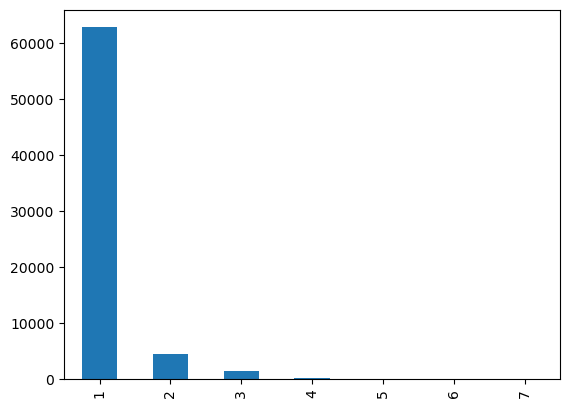

In [34]:
df_legs["id"] = df_legs["ZFT"] + "_" + df_legs["ECH"] + "_" + df_legs["PER"].astype(str) + "_" + df_legs["NDEP"].astype(str)
df_legs.groupby("id").size().value_counts().plot(kind="bar")

In [35]:

# Transform original IDs to integer (they are hierarchichal)
df_households["edgt_household_id"] = (df_households["ZFM"] + df_households["ECH"]).astype(int)
df_households["zone_id"] = df_households["ZFM"].astype(int)

df_persons["edgt_household_id"] = (df_persons["ZFP"] + df_persons["ECH"]).astype(int)
df_persons["edgt_person_id"] = df_persons["PER"].astype(int)

df_trips["edgt_household_id"] = (df_trips["ZFD"] + df_trips["ECH"]).astype(int)
df_trips["edgt_person_id"] = df_trips["PER"].astype(int)
df_trips["edgt_trip_id"] = df_trips["NDEP"].astype(int)

df_legs["edgt_household_id"] = (df_legs["ZFT"] + df_legs["ECH"]).astype(int)
df_legs["edgt_person_id"] = df_legs["PER"].astype(int)
df_legs["edgt_trip_id"] = df_legs["NDEP"].astype(int)
df_legs["edgt_leg_id"] = df_legs["T1"].astype(int)


<Axes: >

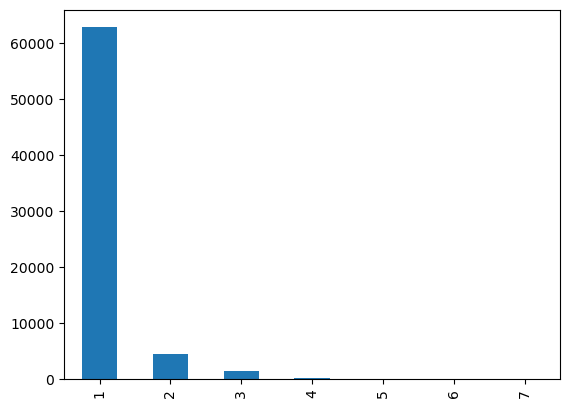

In [36]:
df_legs["id_2"] = df_legs["edgt_household_id"].astype(str) + "_" + df_legs["edgt_person_id"].astype(str) + "_" + df_legs["edgt_trip_id"].astype(str)
df_legs.groupby("id_2").size().value_counts().plot(kind="bar")

In [37]:


# Construct new IDs for households, persons and trips (which are unique globally)
df_households["household_id"] = np.arange(len(df_households))

df_persons = pd.merge(
    df_persons, df_households[["edgt_household_id", "household_id"]],
    on = ["edgt_household_id"]
).sort_values(by = ["household_id", "edgt_person_id"])
df_persons["person_id"] = np.arange(len(df_persons))

df_trips = pd.merge(
    df_trips, df_persons[["edgt_person_id", "edgt_household_id", "person_id", "household_id"]],
    on = ["edgt_person_id", "edgt_household_id"]
).sort_values(by = ["household_id", "person_id", "edgt_trip_id"])
df_trips["trip_id"] = np.arange(len(df_trips))


df_legs = pd.merge(
    df_legs, df_trips[["edgt_trip_id", "edgt_person_id", "edgt_household_id", "person_id", "household_id", "trip_id"]],
    on = ["edgt_trip_id", "edgt_person_id", "edgt_household_id"]
).sort_values(by = ["household_id", "person_id", "trip_id", "edgt_leg_id"])
df_legs["leg_id"] = np.arange(len(df_legs))



In [38]:
df_legs.groupby(["trip_id"]).size().value_counts()

1    62844
2     4498
3     1473
4      234
5       20
6        2
7        1
Name: count, dtype: int64

In [39]:
df_legs.loc[df_legs["trip_id"] == 99575]

,ZFT,ECH,PER,NDEP,T1,T3,T12,T13,id,edgt_household_id,edgt_person_id,edgt_trip_id,edgt_leg_id,id_2,person_id,household_id,trip_id,leg_id


### Households

In [40]:
# Number of vehicles
df_households["number_of_cars"] = df_households["M6"].astype(int)
df_households["number_of_motorbikes"] = df_households["M14"].astype(int)
df_households["number_of_bicycles"] = df_households["M21"].astype(int)

df_households = df_households[[
    "edgt_household_id", "zone_id",
    "household_id", "number_of_cars", 
    "number_of_motorbikes", "number_of_bicycles"]]
    # "income_EUR", "income_per_person_EUR"

### Persons

In [41]:

df_persons["weight"] = df_persons["COEP"].astype(float)
df_persons["age"] = df_persons["P4"].astype(int)
df_persons["has_driving_permit"] = df_persons["P7"] == "1"
# No information about motorbike permit assume true if car permit
df_persons["has_motorbike_permit"] = df_persons["has_driving_permit"]
df_persons["has_pt_subscription"] = df_persons["P12"].isin(["1", "2", "3", "5", "6"])

In [42]:
df_persons = df_persons[[
    "household_id", "person_id", "has_driving_permit", "has_motorbike_permit", "has_pt_subscription", "age", 
    "weight"]]

### Trips

In [43]:
df_trips["mode"] = "pt"
df_trips["mode_code"] = df_trips["MODP"].astype(int)

# Trip mode
for mode, values in MODES_MAP.items():
    df_trips.loc[df_trips["mode_code"].isin(values), "mode"] = mode

In [44]:
df_trips

,ZFD,ECH,PER,NDEP,D2A,D3,D4,D5A,D7,D8,...,D12,MODP,edgt_household_id,edgt_person_id,edgt_trip_id,person_id,household_id,trip_id,mode,mode_code
0,00101001,84,1,1,1,00101001,1045,42,00102001,1100,...,1665,31,10100184,1,1,0,0,0,pt,31
1,00101001,84,1,2,42,00102001,1145,1,00101001,1200,...,1665,31,10100184,1,2,0,0,1,pt,31
2,00101001,84,2,1,1,00101001,820,11,00104001,840,...,3885,31,10100184,2,1,1,0,2,pt,31
3,00101001,84,2,2,11,00104001,1745,1,00101001,1810,...,4125,33,10100184,2,2,1,0,3,pt,33
4,00101001,84,3,1,1,00101001,728,25,00212003,738,...,3585,31,10100184,3,1,2,0,4,pt,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99580,00712451,742,1,1,1,00712451,1700,54,00711006,1710,...,4810,21,712451742,1,1,36561,16359,99580,car,21
99581,00712451,742,1,2,54,00711006,1710,1,00712451,1720,...,4670,21,712451742,1,2,36561,16359,99581,car,21
99582,00712451,781,1,1,1,00712451,730,61,00712001,735,...,1200,21,712451781,1,1,36562,16360,99582,car,21
99583,00712451,781,1,2,63,00712001,737,11,00712451,745,...,1200,21,712451781,1,2,36562,16360,99583,car,21


In [45]:

# Further trip attributes
df_trips["euclidean_distance"] = df_trips["D11"]
df_trips["routed_distance"] = df_trips["D12"]

In [46]:
# Trip times
df_trips["departure_time"] = 3600.0 * (df_trips["D4"] // 100) # hour
df_trips["departure_time"] += 60.0 * (df_trips["D4"] % 100) # minute

df_trips["arrival_time"] = 3600.0 * (df_trips["D8"] // 100) # hour
df_trips["arrival_time"] += 60.0 * (df_trips["D8"] % 100) # minute

df_trips["travel_time"] = df_trips["arrival_time"] - df_trips["departure_time"]

In [47]:

df_trips["origin_cell"] = df_trips["D3"].astype(int)
df_trips["destination_cell"] = df_trips["D7"].astype(int)

In [48]:

# Trip purpose
df_trips["destination_activity_type"] = "invalid"
df_trips["origin_activity_type"] = "invalid"

for purpose, values in PURPOSE_MAP.items():
    df_trips.loc[df_trips["D5A"].isin(values), "destination_activity_type"] = purpose
    df_trips.loc[df_trips["D2A"].isin(values), "origin_activity_type"] = purpose

In [49]:
df_trips = df_trips[[
    "household_id", "person_id", "trip_id", "mode", "mode_code", "euclidean_distance",
    "travel_time", "departure_time",
    "origin_cell", "destination_cell", "origin_activity_type", "destination_activity_type"
]]

### Legs

In [50]:
df_legs

,ZFT,ECH,PER,NDEP,T1,T3,T12,T13,id,edgt_household_id,edgt_person_id,edgt_trip_id,edgt_leg_id,id_2,person_id,household_id,trip_id,leg_id
0,00101001,84,1,1,1,31,1110,1665,00101001_84_1_1,10100184,1,1,1,10100184_1_1,0,0,0,0
1,00101001,84,1,2,1,31,1110,1665,00101001_84_1_2,10100184,1,2,1,10100184_1_2,0,0,1,1
2,00101001,84,2,1,1,31,2590,3885,00101001_84_2_1,10100184,2,1,1,10100184_2_1,1,0,2,2
3,00101001,84,2,2,1,33,2260,3390,00101001_84_2_2,10100184,2,2,1,10100184_2_2,1,0,3,3
4,00101001,84,2,2,2,32,490,735,00101001_84_2_2,10100184,2,2,2,10100184_2_2,1,0,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77309,00712451,742,1,1,1,21,3610,4810,00712451_742_1_1,712451742,1,1,1,712451742_1_1,36561,16359,99580,77309
77310,00712451,742,1,2,1,21,3610,4670,00712451_742_1_2,712451742,1,2,1,712451742_1_2,36561,16359,99581,77310
77311,00712451,781,1,1,1,21,770,1200,00712451_781_1_1,712451781,1,1,1,712451781_1_1,36562,16360,99582,77311
77312,00712451,781,1,2,1,21,770,1200,00712451_781_1_2,712451781,1,2,1,712451781_1_2,36562,16360,99583,77312


In [51]:

df_legs["mode"] = "other"
df_legs["transit_mode"] = "other"
df_legs["mode_code"] = df_legs["T3"]
df_legs["euclidean_distance"] = df_legs["T12"]

for category, (leg_mode, transit_mode) in LEG_MODES_MAP.items():
    df_legs.loc[df_legs["mode_code"] == category, "mode"] = leg_mode
    df_legs.loc[df_legs["mode_code"] == category, "transit_mode"] = transit_mode

In [52]:
df_legs = df_legs[["household_id", "person_id", "trip_id", "leg_id",
    "mode", "transit_mode", "mode_code", "euclidean_distance"]]

### Checking for NaN

In [53]:
# Households, persons, legs don't have any NaNs
# Trips has some NaNs for trips that go out of the region, we add a dummy to indicate that

df_trips["is_valid"] = True

for column in df_trips.columns:
    f = df_trips[column].isna()
    df_trips.loc[f, "is_valid"] = False

    if np.count_nonzero(f) > 0:
        print(column, np.count_nonzero(f))

C:\Users\lebescond\AppData\Local\Temp\ipykernel_7732\667833256.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trips["is_valid"] = True


### Output

In [54]:
df_households.to_parquet("{}/households.parquet".format(output_path))
df_persons.to_parquet("{}/persons.parquet".format(output_path))
df_trips.to_parquet("{}/trips.parquet".format(output_path))
df_legs.to_parquet("{}/legs.parquet".format(output_path))